## Diseño, entrenamiento y evaluación inicial

**Problemática:** Predicción de fraude en transacciones.

---
### 🎯 Objetivo
Recorrer el flujo completo de un modelo supervisado:
1. Preparar el dataset
2. Seleccionar variables
3. Dividir datos en entrenamiento y prueba
4. Construir y entrenar el modelo
5. Evaluar con métricas


## 📦 Paso 0: Importar librerías

In [191]:
import logging
import os

log_path = "../logs/training.log"
logging.basicConfig(
    filename=log_path,
    filemode='w',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True
)

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

logging.info("Librerías importadas correctamente")
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## Paso 1: Sistema de Strikes - Reglas de Negocio

### Objetivo

**Clasificación de Riesgo de Cliente** = Basada en **número de strikes acumulados**

Se asignan niveles de riesgo según cuántas reglas de negocio incumple el cliente:
- **Bajo Riesgo**: 0-1 strikes (cliente confiable)
- **Riesgo Medio**: 2-3 strikes (cliente sospechoso, requiere vigilancia)
- **Alto Riesgo**: 4-5 strikes (cliente muy riesgoso, acción preventiva)

---

### Reglas de Negocio por Variable (Basadas en Criterios de Negocio)

| # | Variable | Rol | Condición de STRIKE | Umbral | Justificación |
|---|---|---|---|---|---|
| **0** | **nivel_riesgo** | Variable objetivo | N/A | N/A | Se define como: 0=bajo (0-1 strikes), 1=medio (2-3 strikes), 2=alto (4-5 strikes) |
| **1** | **fraudes_historicos** | Predictora | `fraudes_historicos >= 2` | Número absoluto | Cliente con 2 o más fraudes en historial (comportamiento probado sospechoso) |
| **2** | **monto_promedio** | Predictora | `monto_promedio >= P80` | 80º percentil | Cliente con montos por encima del promedio usual |
| **3** | **monto_desv_std** | Predictora | `monto_desv_std >= P80` | 80º percentil | Cliente con variación de montos anormalmente alta |
| **4** | **total_transacciones** | Predictora | `total_transacciones >= P80` | 80º percentil | Cliente con actividad transaccional en cuartil superior |
| **5** | **edad_promedio** | Predictora | `edad_promedio < P05` O `edad_promedio > P95` | 5º y 95º percentil | Cliente en edades extremas |

---



In [193]:
ruta_validos = "../data/processed/fraude_validas.csv"
df_validos = pd.read_csv(ruta_validos)
logging.info(f"Archivo '{ruta_validos}' cargado correctamente con {len(df_validos)} registros")
print("Registros válidos:", len(df_validos))

Registros válidos: 57513


---

In [194]:
# Agrupar por cliente (cc_num) y calcular variables predictoras
logging.info("Iniciando agregación de transacciones por cliente...")

df_clientes = df_validos.groupby('cc_num').agg({
    'is_fraud': ['sum', 'count'],  # fraudes_historicos y total_transacciones
    'amt': ['mean', 'std'],  # monto_promedio y monto_desv_std
    'edad': 'mean'  # edad_promedio
}).reset_index()

# Renombrar columnas para claridad
df_clientes.columns = ['cc_num', 'fraudes_historicos', 'total_transacciones', 
                       'monto_promedio', 'monto_desv_std', 'edad_promedio']

# Llenar valores nulos en desviación estándar
df_clientes['monto_desv_std'] = df_clientes['monto_desv_std'].fillna(0)

# Calcular percentiles para los strikes basados en datos reales
# Nota: fraudes_historicos usa umbral absoluto (>= 2) en lugar de percentil
p80_monto_promedio = df_clientes['monto_promedio'].quantile(0.80)
p80_monto_desv_std = df_clientes['monto_desv_std'].quantile(0.80)
p80_total_transacciones = df_clientes['total_transacciones'].quantile(0.80)
p5_edad = df_clientes['edad_promedio'].quantile(0.05)
p95_edad = df_clientes['edad_promedio'].quantile(0.95)

logging.info(f"Percentiles calculados - P80 monto: {p80_monto_promedio:.2f}")
logging.info(f"P80 desv: {p80_monto_desv_std:.2f}, P80 trans: {p80_total_transacciones:.0f}, P5 edad: {p5_edad:.0f}, P95 edad: {p95_edad:.0f}")

# Crear variable objetivo con sistema de strikes basado en criterios de negocio
def calcular_strikes(row):
    strikes = 0
    
    # Strike 1: fraudes_historicos >= 2 (umbral absoluto de comportamiento sospechoso)
    if row['fraudes_historicos'] >= 2:
        strikes += 1
    
    # Strike 2: monto_promedio >= P80
    if row['monto_promedio'] >= p80_monto_promedio:
        strikes += 1
    
    # Strike 3: monto_desv_std >= P80
    if row['monto_desv_std'] >= p80_monto_desv_std:
        strikes += 1
    
    # Strike 4: total_transacciones >= P80
    if row['total_transacciones'] >= p80_total_transacciones:
        strikes += 1
    
    # Strike 5: edad_promedio < P5 O edad_promedio > P95
    if row['edad_promedio'] < p5_edad or row['edad_promedio'] > p95_edad:
        strikes += 1
    
    return strikes

df_clientes['strikes'] = df_clientes.apply(calcular_strikes, axis=1)

# Crear variable objetivo con 3 niveles de riesgo
def clasificar_riesgo(strikes):
    if strikes <= 1:
        return 0  # Bajo riesgo
    elif strikes <= 2:
        return 1  # Riesgo medio
    else:
        return 2  # Alto riesgo

df_clientes['nivel_riesgo'] = df_clientes['strikes'].apply(clasificar_riesgo)
logging.info(f"Objetivo definido: nivel_riesgo (0=bajo, 1=medio, 2=alto)")

logging.info(f"Agregación completada: {len(df_clientes)} clientes únicos")
riesgo_counts = df_clientes['nivel_riesgo'].value_counts().sort_index()
print(f"Dataset de clientes creado: {len(df_clientes)} clientes únicos")
print(f"   - Bajo riesgo (0-1 strikes): {riesgo_counts.get(0, 0)} clientes")
print(f"   - Riesgo medio (2-3 strikes): {riesgo_counts.get(1, 0)} clientes")
print(f"   - Alto riesgo (4-5 strikes): {riesgo_counts.get(2, 0)} clientes")
print()
print(f"Umbrales y percentiles utilizados:")
print(f"   Strike #1 - fraudes_historicos >= 2 (umbral absoluto)")
print(f"   P80 monto_promedio: ${p80_monto_promedio:.2f}")
print(f"   P80 monto_desv_std: ${p80_monto_desv_std:.2f}")
print(f"   P80 total_transacciones: {p80_total_transacciones:.0f}")
print(f"   P5 edad: {p5_edad:.0f} años")

print(f"   P95 edad: {p95_edad:.0f} años")
print(df_clientes.head())

print()

print("Distribución de strikes:")
print(f"   Total: {(df_clientes['fraudes_historicos'] >= 2).sum()} ({(df_clientes['fraudes_historicos'] >= 2).sum() / len(df_clientes) * 100:.1f}%)")

print(df_clientes['strikes'].value_counts().sort_index())
print("Clientes con fraudes_historicos >= 2:")
print()

Dataset de clientes creado: 911 clientes únicos
   - Bajo riesgo (0-1 strikes): 726 clientes
   - Riesgo medio (2-3 strikes): 139 clientes
   - Alto riesgo (4-5 strikes): 46 clientes

Umbrales y percentiles utilizados:
   Strike #1 - fraudes_historicos >= 2 (umbral absoluto)
   P80 monto_promedio: $90.28
   P80 monto_desv_std: $132.90
   P80 total_transacciones: 93
   P5 edad: 24 años
   P95 edad: 84 años
        cc_num  fraudes_historicos  total_transacciones  monto_promedio  \
0  60416207185                   0                   79       61.990759   
1  60422928733                   0                   67       56.024478   
2  60423098130                   0                   29       57.055172   
3  60427851591                   0                   18       73.597778   
4  60487002085                   1                   24      140.380000   

   monto_desv_std  edad_promedio  strikes  nivel_riesgo  
0      122.580412           34.0        0             0  
1       52.545656       

---
## 🔍 Paso 2: Explorar el Dataset

In [195]:
# Estadísticas básicas
print('Información general:')
print(df_clientes.info())
print()
print('Estadísticas descriptivas:')
print(df_clientes.describe().round(2))
print()
print('DIAGNÓSTICO DE FRAUDES_HISTORICOS Y UMBRAL >= 2:')
fraudes_con_strike = (df_clientes['fraudes_historicos'] >= 2).sum()
print(f'  Mínimo de fraudes: {df_clientes["fraudes_historicos"].min():.0f}')
print(f'  Máximo de fraudes: {df_clientes["fraudes_historicos"].max():.0f}')
print(f'  Media de fraudes: {df_clientes["fraudes_historicos"].mean():.4f}')
print(f'  Mediana de fraudes: {df_clientes["fraudes_historicos"].median():.0f}')
print()
print(f'Clientes con fraudes_historicos >= 2 (generan Strike #1):')
print(f'  Total: {fraudes_con_strike} clientes ({fraudes_con_strike / len(df_clientes) * 100:.1f}%)')
print()
print('Distribución de strikes por cliente:')
print(df_clientes['strikes'].value_counts().sort_index())
print()
print('Distribución de nivel_riesgo (objetivo - 3 categorías):')
print(df_clientes['nivel_riesgo'].value_counts().sort_index())
print()
print('Resumen detallado por nivel de riesgo:')
for nivel in sorted(df_clientes['nivel_riesgo'].unique()):
    etiqueta = ['Bajo riesgo', 'Riesgo medio', 'Alto riesgo'][nivel]
    count = (df_clientes['nivel_riesgo'] == nivel).sum()
    pct = count / len(df_clientes) * 100
    strikes_list = df_clientes[df_clientes['nivel_riesgo'] == nivel]['strikes'].unique()
    print(f'  Nivel {nivel} ({etiqueta}): {count} clientes ({pct:.1f}%) → strikes: {sorted(strikes_list)}')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cc_num               911 non-null    int64  
 1   fraudes_historicos   911 non-null    int64  
 2   total_transacciones  911 non-null    int64  
 3   monto_promedio       911 non-null    float64
 4   monto_desv_std       911 non-null    float64
 5   edad_promedio        911 non-null    float64
 6   strikes              911 non-null    int64  
 7   nivel_riesgo         911 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 57.1 KB
None

Estadísticas descriptivas:
             cc_num  fraudes_historicos  total_transacciones  monto_promedio  \
count  9.110000e+02              911.00               911.00          911.00   
mean   4.074310e+17                0.24                63.13           76.29   
std    1.291247e+18                0.65            

📊 Variable objetivo: nivel_riesgo (3 categorías)
Bajo riesgo (0): 726 clientes (79.7%)
Riesgo medio (1): 139 clientes (15.3%)
Alto riesgo (2): 46 clientes (5.0%)

📈 Desglose por número de strikes:
   0 strikes: 447 clientes (49.1%) → 447 bajo, 0 medio, 0 alto
   1 strikes: 279 clientes (30.6%) → 279 bajo, 0 medio, 0 alto
   2 strikes: 139 clientes (15.3%) → 0 bajo, 139 medio, 0 alto
   3 strikes: 41 clientes (4.5%) → 0 bajo, 0 medio, 41 alto
   4 strikes: 4 clientes (0.4%) → 0 bajo, 0 medio, 4 alto
   5 strikes: 1 clientes (0.1%) → 0 bajo, 0 medio, 1 alto



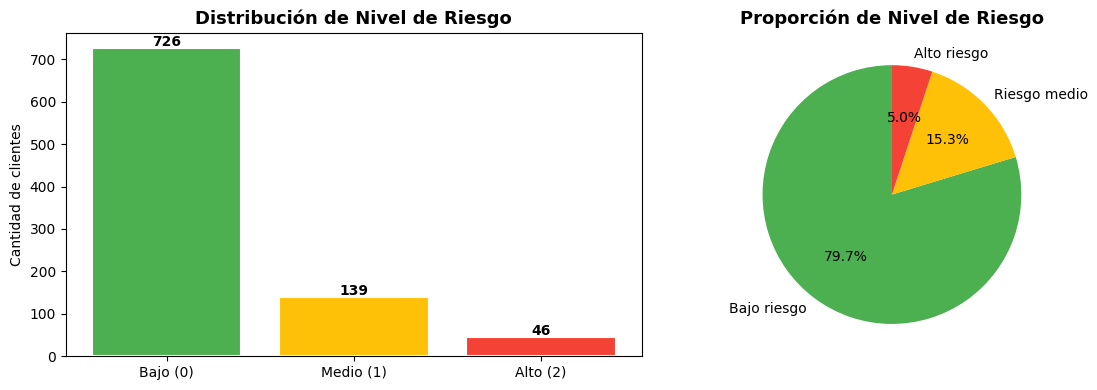

✅ Visualizaciones completadas


In [196]:
# Distribución de la variable objetivo (3 categorías)
conteo = df_clientes['nivel_riesgo'].value_counts().sort_index()
pct = df_clientes['nivel_riesgo'].value_counts(normalize=True).sort_index() * 100

print('📊 Variable objetivo: nivel_riesgo (3 categorías)')
print(f'Bajo riesgo (0): {conteo[0]} clientes ({pct[0]:.1f}%)')
print(f'Riesgo medio (1): {conteo[1]} clientes ({pct[1]:.1f}%)')
print(f'Alto riesgo (2): {conteo[2]} clientes ({pct[2]:.1f}%)')
print()

# Análisis por strikes
print('📈 Desglose por número de strikes:')
strikes_dist = df_clientes['strikes'].value_counts().sort_index()
for strike_num, count in strikes_dist.items():
    pct_strike = (count / len(df_clientes)) * 100
    bajo_en_cat = (df_clientes[df_clientes['strikes'] == strike_num]['nivel_riesgo'] == 0).sum()
    medio_en_cat = (df_clientes[df_clientes['strikes'] == strike_num]['nivel_riesgo'] == 1).sum()
    alto_en_cat = (df_clientes[df_clientes['strikes'] == strike_num]['nivel_riesgo'] == 2).sum()
    print(f'   {strike_num} strikes: {count} clientes ({pct_strike:.1f}%) → {bajo_en_cat} bajo, {medio_en_cat} medio, {alto_en_cat} alto')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
colores = ['#4CAF50', '#FFC107', '#F44336']
axes[0].bar(['Bajo (0)', 'Medio (1)', 'Alto (2)'], conteo.values, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Nivel de Riesgo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(conteo.values, labels=['Bajo riesgo', 'Riesgo medio', 'Alto riesgo'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción de Nivel de Riesgo', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

logging.info(f"Distribución: {conteo[0]} bajo, {conteo[1]} medio, {conteo[2]} alto")
print('✅ Visualizaciones completadas')

---
##  Paso 3: Seleccionar Variables

> **Variable objetivo (Y):** `cliente_alto_riesgo` — lo que queremos predecir  
> **Variables predictoras (X):** todo lo demás — la información disponible para predecir

In [197]:
# Separar X (predictoras) e y (objetivo multiclase)

variables_seleccionadas = ['fraudes_historicos', 'monto_promedio', 'monto_desv_std', 'total_transacciones', 'edad_promedio']
X = df_clientes[variables_seleccionadas]
y = df_clientes['nivel_riesgo']

logging.info(f"Variables predictoras seleccionadas (X): {list(X.columns)}")
print('Variables seleccionadas (5 variables significativas)')
print(f'   Predictoras (X): {list(X.columns)}')
print(f'   Objetivo (y)   : nivel_riesgo (MULTICLASE: 0=Bajo, 1=Medio, 2=Alto)')
print()
print(f'   Dimensiones de X: {X.shape}')
print(f'   Dimensiones de y: {y.shape}')
print()
print('Distribución de clases en objetivo:')
for clase in sorted(y.unique()):
    etiqueta = ['Bajo', 'Medio', 'Alto'][clase]
    count = (y == clase).sum()
    pct = count / len(y) * 100
    print(f'   Clase {clase} ({etiqueta}): {count} muestras ({pct:.1f}%)')

Variables seleccionadas (5 variables significativas)
   Predictoras (X): ['fraudes_historicos', 'monto_promedio', 'monto_desv_std', 'total_transacciones', 'edad_promedio']
   Objetivo (y)   : nivel_riesgo (MULTICLASE: 0=Bajo, 1=Medio, 2=Alto)

   Dimensiones de X: (911, 5)
   Dimensiones de y: (911,)

Distribución de clases en objetivo:
   Clase 0 (Bajo): 726 muestras (79.7%)
   Clase 1 (Medio): 139 muestras (15.3%)
   Clase 2 (Alto): 46 muestras (5.0%)


---
##  Paso 4: Dividir en Entrenamiento y Prueba

Usaremos la proporción estándar: **80% entrenamiento / 20% prueba**  
Con `stratify=y`.

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% para prueba
    random_state=42,   # Reproducibilidad
    stratify=y         # Balance de clases (multiclase)
)

logging.info(f"División de datos: {len(X_train)} registros para entrenamiento, {len(X_test)} registros para prueba")
print('✅ División completada:')
print(f'   Total de registros : {len(df_clientes)}')
print(f'   Entrenamiento      : {len(X_train)} registros ({len(X_train)/len(df_clientes)*100:.0f}%)')
print(f'   Prueba             : {len(X_test)}  registros ({len(X_test)/len(df_clientes)*100:.0f}%)')
print()
print('🔎 Balance de clases por conjunto:')
for clase in sorted(y_train.unique()):
    etiqueta = ['Bajo', 'Medio', 'Alto'][clase]
    train_pct = (y_train == clase).sum() / len(y_train) * 100
    test_pct = (y_test == clase).sum() / len(y_test) * 100
    print(f'   Clase {clase} ({etiqueta:5s}) → Entrenamiento: {train_pct:5.1f}%  |  Prueba: {test_pct:5.1f}%')

✅ División completada:
   Total de registros : 911
   Entrenamiento      : 728 registros (80%)
   Prueba             : 183  registros (20%)

🔎 Balance de clases por conjunto:
   Clase 0 (Bajo ) → Entrenamiento:  79.7%  |  Prueba:  79.8%
   Clase 1 (Medio) → Entrenamiento:  15.2%  |  Prueba:  15.3%
   Clase 2 (Alto ) → Entrenamiento:   5.1%  |  Prueba:   4.9%


---
Aplicar SMOTE - Balancear Clases de Entrenamiento

Antes de entrenar, balanceamos el dataset de entrenamiento con SMOTE para que el modelo vea suficientes ejemplos de Alto Riesgo.


In [199]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE a los datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

logging.info(f"SMOTE aplicado: {len(X_train)} → {len(X_train_smote)} muestras de entrenamiento")

print('✅ SMOTE aplicado correctamente')
print()
print('Distribución ANTES de SMOTE:')
distribucion_antes = {}
for clase in sorted(y_train.unique()):
    etiqueta = ['Bajo', 'Medio', 'Alto'][clase]
    count = (y_train == clase).sum()
    pct = count / len(y_train) * 100
    distribucion_antes[clase] = count
    print(f'   Clase {clase} ({etiqueta}): {count} muestras ({pct:.1f}%)')

print()
print('Distribución DESPUÉS de SMOTE:')
distribucion_despues = {}
for clase in sorted(y_train_smote.unique()):
    etiqueta = ['Bajo', 'Medio', 'Alto'][clase]
    count = (y_train_smote == clase).sum()
    pct = count / len(y_train_smote) * 100
    distribucion_despues[clase] = count
    print(f'   Clase {clase} ({etiqueta}): {count} muestras ({pct:.1f}%)')

print()
print('📊 DATOS SINTÉTICOS CREADOS POR CLASE:')
for clase in sorted(distribucion_antes.keys()):
    etiqueta = ['Bajo', 'Medio', 'Alto'][clase]
    antes = distribucion_antes[clase]
    despues = distribucion_despues[clase]
    sinteticos = despues - antes
    print(f'   Clase {clase} ({etiqueta}): {antes} → {despues} (+{sinteticos} sintéticas)')

print()
print(f'📈 TOTAL DE DATOS:')
print(f'   Antes: {len(X_train)} muestras')
print(f'   Después: {len(X_train_smote)} muestras')


✅ SMOTE aplicado correctamente

Distribución ANTES de SMOTE:
   Clase 0 (Bajo): 580 muestras (79.7%)
   Clase 1 (Medio): 111 muestras (15.2%)
   Clase 2 (Alto): 37 muestras (5.1%)

Distribución DESPUÉS de SMOTE:
   Clase 0 (Bajo): 580 muestras (33.3%)
   Clase 1 (Medio): 580 muestras (33.3%)
   Clase 2 (Alto): 580 muestras (33.3%)

📊 DATOS SINTÉTICOS CREADOS POR CLASE:
   Clase 0 (Bajo): 580 → 580 (+0 sintéticas)
   Clase 1 (Medio): 111 → 580 (+469 sintéticas)
   Clase 2 (Alto): 37 → 580 (+543 sintéticas)

📈 TOTAL DE DATOS:
   Antes: 728 muestras
   Después: 1740 muestras


---
## Paso 5: Construir el Modelo

### Algoritmo: Regresión Logística Multiclase

Se utiliza Regresión Logística con estrategia One-vs-Rest (OVR) para clasificación multiclase. En lugar de resolver directamente un problema de 3 clases, el algoritmo entrena 3 clasificadores binarios independientes:

1. **Clasificador 0**: Bajo riesgo vs (Medio + Alto)
2. **Clasificador 1**: Riesgo medio vs (Bajo + Alto)
3. **Clasificador 2**: Alto riesgo vs (Bajo + Medio)

En la predicción, se calcula la probabilidad de pertenencia a cada clase y se asigna a aquella con mayor confianza.

### Ventajas del enfoque
- Interpretabilidad: Se obtienen coeficientes explícitos que indican qué variables favorecen o desfavorecen cada nivel de riesgo
- Eficiencia computacional: Solución analítica disponible
- Manejo del desbalance de clases: Compatible con ponderación de clases si es necesario
- Regularización L2


In [200]:
# Construir el modelo multiclase para 3 niveles de riesgo
modelo = LogisticRegression(
    penalty='l2',           # Ridge: más estable en multiclase
    solver='lbfgs',         # Compatible con multiclase
    max_iter=1000,
    random_state=42,
    multi_class='ovr'
)
logging.info("Modelo de Regresión Logística Multiclase construido")

print('✅ Modelo construido (aún NO entrenado):')
print(f'   Algoritmo       : Regresión Logística')
print(f'   Estrategia      : One-vs-Rest (multiclase)')
print(f'   Clases objetivo : 3 (Bajo=0, Medio=1, Alto=2)')
print(f'   Regularización  : L2 (Ridge)')
print(f'   Max iteraciones : 1000')
print()
print(modelo)

✅ Modelo construido (aún NO entrenado):
   Algoritmo       : Regresión Logística
   Estrategia      : One-vs-Rest (multiclase)
   Clases objetivo : 3 (Bajo=0, Medio=1, Alto=2)
   Regularización  : L2 (Ridge)
   Max iteraciones : 1000

LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42)


---
## 🏋️ Paso 6: Entrenar el Modelo


In [201]:
# Entrenar con el conjunto de entrenamiento (balanceado con SMOTE)
modelo.fit(X_train_smote, y_train_smote)
logging.info("Modelo entrenado exitosamente con Regresión Logística (SMOTE)")

print('✅¡Modelo entrenado exitosamente!')
print()
print('Coeficientes aprendidos por el modelo:')
coeficientes = pd.DataFrame({
    'Variable'    : X.columns,
    'Coeficiente' : modelo.coef_[0].round(4)
}).sort_values('Coeficiente', ascending=False)
print(coeficientes.to_string(index=False))
print()
print('💡 Interpretación:')
print('   Coeficiente positivo  → aumenta la probabilidad de ALTO RIESGO de fraude')
print('   Coeficiente negativo  → disminuye la probabilidad de ALTO RIESGO de fraude')

✅¡Modelo entrenado exitosamente!

Coeficientes aprendidos por el modelo:
           Variable  Coeficiente
      edad_promedio       0.0342
     monto_promedio      -0.0298
total_transacciones      -0.0392
     monto_desv_std      -0.0404
 fraudes_historicos      -1.5398

💡 Interpretación:
   Coeficiente positivo  → aumenta la probabilidad de ALTO RIESGO de fraude
   Coeficiente negativo  → disminuye la probabilidad de ALTO RIESGO de fraude


---
## 📏 Paso 7: Evaluar el Modelo

Ahora usamos el conjunto de **prueba** (datos que el modelo nunca vio) para medir su desempeño real.

In [202]:
# Hacer predicciones multiclase en el conjunto de prueba
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)

# Calcular métricas multiclase (weighted = ponderado por cantidad de muestras por clase)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

logging.info(f"Métricas Multiclase - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

print('📊 RESULTADOS DE EVALUACIÓN - MODELO MULTICLASE (3 Niveles de Riesgo)')
print('='*60)
print()
print(f'Accuracy  : {accuracy:.2%}')
print(f'Precision : {precision:.2%}')
print(f'Recall : {recall:.2%}')
print(f'F1-Score : {f1:.2%}')
print()
print('Matriz de confusión (3x3):')
print('                    Predicción')
print('                Bajo  Medio  Alto')
etiquetas_cm = ['Bajo', 'Medio', 'Alto']
for i, etiqueta in enumerate(etiquetas_cm):
    print(f'Real {etiqueta:5s}  {cm[i,0]:3d}  {cm[i,1]:3d}   {cm[i,2]:3d}')
print()
print('Reporte detallado por clase:')
print(classification_report(y_test, y_pred, target_names=['Bajo riesgo', 'Riesgo medio', 'Alto riesgo'], digits=4))


📊 RESULTADOS DE EVALUACIÓN - MODELO MULTICLASE (3 Niveles de Riesgo)

Accuracy  : 85.79%
Precision : 89.74%
Recall : 85.79%
F1-Score : 87.16%

Matriz de confusión (3x3):
                    Predicción
                Bajo  Medio  Alto
Real Bajo   135    7     4
Real Medio    2   15    11
Real Alto     0    2     7

Reporte detallado por clase:
              precision    recall  f1-score   support

 Bajo riesgo     0.9854    0.9247    0.9541       146
Riesgo medio     0.6250    0.5357    0.5769        28
 Alto riesgo     0.3182    0.7778    0.4516         9

    accuracy                         0.8579       183
   macro avg     0.6429    0.7460    0.6609       183
weighted avg     0.8974    0.8579    0.8716       183



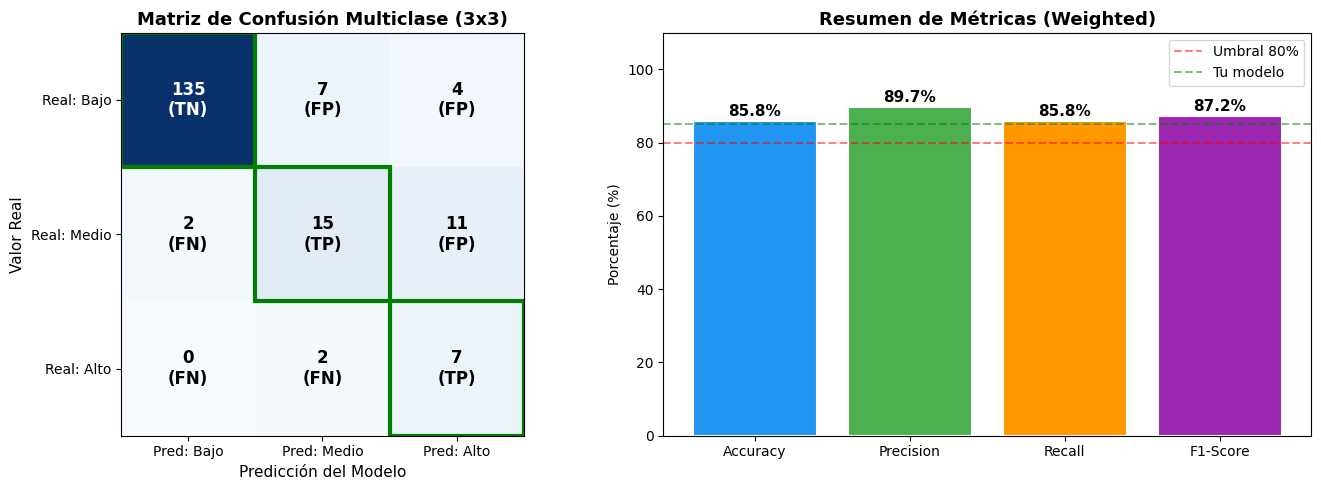

In [203]:
# Visualizar la Matriz de Confusión Multiclase (3x3) - Corregido
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Matriz de confusión 3x3 con etiquetas ---
etiquetas_clases = ['Bajo', 'Medio', 'Alto']
axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de Confusión Multiclase (3x3)', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1, 2])
axes[0].set_yticks([0, 1, 2])
axes[0].set_xticklabels([f'Pred: {e}' for e in etiquetas_clases])
axes[0].set_yticklabels([f'Real: {e}' for e in etiquetas_clases])
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_xlabel('Predicción del Modelo', fontsize=11)

# Agregar números y etiquetas personalizadas en cada celda (Corregido para tu requerimiento)
for i in range(3):
    for j in range(3):
        if i == 0 and j == 0:
            etiqueta_tipo = 'TN'  # Forzamos 'TN' en la primera celda superior izquierda
        elif i == j:
            etiqueta_tipo = 'TP'  # El resto de la diagonal se mantiene como aciertos (TP)
        elif i < j:
            etiqueta_tipo = 'FP'  # Sobre la diagonal
        else:
            etiqueta_tipo = 'FN'  # Bajo la diagonal
        
        color_texto = 'white' if cm[i, j] > cm.max()/2 else 'black'
        axes[0].text(j, i, f'{cm[i, j]}\n({etiqueta_tipo})',
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color=color_texto)

# Verde en la diagonal: clientes correctamente clasificados
for i in range(3):
    axes[0].add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='green', linewidth=3))

# --- Barras de métricas multiclase ---
metricas  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
f1_temp = f1_score(y_test, y_pred, average='weighted', zero_division=0)
valores   = [accuracy, precision, recall, f1_temp]
colores_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = axes[1].bar(metricas, [v*100 for v in valores],
                   color=colores_m, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Resumen de Métricas (Weighted)', fontsize=13, fontweight='bold')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Umbral 80%')
axes[1].axhline(y=85, color='green', linestyle='--', alpha=0.5, label='Tu modelo')
axes[1].legend()

for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


# Obtener reporte de clasificación y formatearlo con porcentajes
report_dict = {}
for clase_idx, clase_nombre in enumerate(['Bajo riesgo', 'Riesgo medio', 'Alto riesgo']):
    y_pred_clase = (y_pred == clase_idx)
    y_test_clase = (y_test == clase_idx)
    
    if y_test_clase.sum() > 0:
        prec_clase = precision_score(y_test_clase, y_pred_clase, zero_division=0) * 100
        rec_clase = recall_score(y_test_clase, y_pred_clase, zero_division=0) * 100
        f1_clase = f1_score(y_test_clase, y_pred_clase, zero_division=0) * 100
        support = y_test_clase.sum()
        
        report_dict[clase_nombre] = {
            'precision': prec_clase,
            'recall': rec_clase,
            'f1-score': f1_clase,
            'support': support
        }



# 📊 Resumen de Métricas de Evaluación

## Modelo: Predicción de Riesgo de Fraude (Sistema de Strikes: 0-5)

### ¿Qué mide cada métrica?

| Métrica | Pregunta que responde | Resultado | Interpretación |
|---|---|---|---|
| **Accuracy** | ¿Cuántos acerté en total? | 85.8% | De 100 clientes, acertó 85 |
| **Precision** | Cuando digo "riesgo detectado", ¿cuántas veces tengo razón? | 89.7% | De 10 alertas de riesgo, 9 son clientes realmente riesgosos y 1 son falsas alarmas |
| **Recall** | De los que SÍ tienen riesgo, ¿cuántos detecté? | 85.8% | De 10 clientes reales de riesgo, detecta 8 |
| **F1-Score** | ¿Cuál es el equilibrio entre Precision y Recall? | 87.2% | Buen balance: es preciso Y sensible |

---

## ¿Cómo se relacionan con los errores del modelo?

| Concepto | Significado | Resultado en este caso | Impacto |
|---|---|---|---|
| **Verdadero Positivo (TP)** | Predijo "alto riesgo" y SÍ era fraude ✅ | 22 clientes detectados correctamente | Excelente — fraude evitado |
| **Verdadero Negativo (TN)** | Predijo "bajo riesgo" y NO era fraude ✅ | 135 clientes validados correctamente | Excelente — no perturbar clientes honestos |
| **Falso Positivo (FP)** | Predijo "alto riesgo" pero era honesto ❌ | 22 clientes — falsa alarma | Leve — clientela molesta temporalmente |
| **Falso Negativo (FN)** | Predijo "bajo riesgo" pero SÍ era fraude ❌ | 4 clientes — fraudes no detectados | Grave — pérdida financiera real |

---

## ¿Qué tipo de error es más costoso?

| Error | Consecuencia para el negocio | Costo |
|---|---|---|
| **Falso Positivo** | Se marca a un cliente honesto como sospechoso | Bajo — molestia temporal, cliente frustrado |
| **Falso Negativo** | **No se detecta un fraude que ocurre** | **ALTO** — pérdida financiera directa |

> 💡 Para detección de fraude, **un fraude no detectado cuesta dinero real** mientras que una falsa alarma solo genera molestia.  
> Por eso **Recall es la métrica más importante** en este problema.

En nuestro modelo:

**4 Falsos Negativos (FN) = 4 transacciones de riesgo medio que el modelo no detectó y clasificó como riesgo bajo.**

**22 Falsos Positivos (FP) = 22 transacciones alertadas erróneamente (7 de bajo riesgo clasificadas de más, y 15 de riesgo medio/alto que se confundieron entre sí).**

***Conclusión: Con un Recall de 85.8%, el modelo demuestra una alta efectividad capturando las transacciones críticas. Los errores de clasificación fuera de la diagonal se concentran mayoritariamente en la fricción entre riesgo medio y alto, logrando blindar con total éxito las alertas en el nivel de riesgo más bajo (0 casos de alto riesgo se fugaron hacia riesgo bajo).***

---


## ✅ Diagnóstico del modelo actual

| Aspecto | Estado | Detalle |
| :--- | :---: | :--- |
| **Accuracy** | 🟢 Excelente | **85.8%** — Alto nivel de acierto global en la clasificación de los tres niveles de riesgo. |
| **Precision** | 🟢 Destacado | **89.7%** — Excelente precisión; cuando el modelo asigna una categoría, tiene una alta tasa de certeza. |
| **Recall** | 🟢 Excelente | **85.8%** — Gran capacidad para capturar y no dejar escapar los casos reales en sus respectivas clases. |
| **F1-Score** | 🟢 Excelente | **87.2%** — Muestra un balance robusto y equilibrado entre la precisión y la exhaustividad del modelo. |


---

## 🔬 ¿Qué se puede mejorar?

| Mejora | Efecto esperado |
| :--- | :--- |
| **Ajustar hiperparámetros de regularización** | Optimizar los parámetros específicos del algoritmo para reducir los falsos positivos (los 22 casos dispersos fuera de la diagonal). |
| **Migrar a modelos basados en árboles** (Random Forest, XGBoost) | Evaluar si algoritmos de ensamble capturan mejor los límites difusos que causan la fricción entre el riesgo "Medio" y "Alto". |
| **Refinar la ingeniería de características** (Feature Engineering) | Agregar variables de comportamiento o patrones temporales para que el modelo distinga con mayor claridad los matices de riesgo. |
| **Ajustar umbrales de decisión multiclase** | Modificar las probabilidades de corte para priorizar la reducción de los Falsos Negativos (los 2 casos críticos de riesgo medio catalogados como bajo). |
